# Evaluate Mixed-Dataset Models

This notebook reloads the trained detectors (ResNet-101 baseline, ViT-B/16, and Swin-T) and visualizes their predictions on Waymo and nuScenes samples. All explanations and outputs are in English for report integration.

In [44]:
import os
import sys
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch

# Locate project root (directory that contains 'src')
PROJECT_ROOT = None
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate.resolve()
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate project root from the current working directory.")

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "DeepDataMiningLearning" / "detection"))

print(f"Project root: {PROJECT_ROOT}")
SAVE_FIGURES = True
IMAGES_DIR = PROJECT_ROOT / "reports" / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


Project root: /Users/shawn/Documents/sjsu/2025-2/ia/customRCNN


In [45]:
from torch.utils.data import Subset

from src.dataset.load_dataset import (
    load_waymo_dataset,
    load_nuscenes_dataset,
    WAYMO_CLASS_NAMES,
)
from src.modeling.advanced_backbone_rcnn import AdvancedBackboneRCNN
from src.modeling.modeling_rpnfasterrcnn import CustomRCNN


In [46]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Helper Functions

In [47]:
import re
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

def slugify(text: str) -> str:
    return re.sub(r'[^a-z0-9]+', '_', text.lower()).strip('_')

LABEL_MAP = {
    1: "Vehicle",
    2: "Pedestrian",
    3: "Cyclist",
    4: "Sign",
}

def tensor_to_rgb(image_tensor: torch.Tensor) -> np.ndarray:
    '''Convert a CxHxW tensor to an RGB numpy array in [0, 1].'''
    img = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    if img.min() < 0.0 or img.max() > 1.0:
        img = img * IMAGENET_STD + IMAGENET_MEAN
    img = np.clip(img, 0.0, 1.0)
    return img

def fetch_samples(dataset, count: int):
    count = min(count, len(dataset))
    indices = list(range(count))
    return [dataset[idx] for idx in indices]

def run_inference(model: torch.nn.Module, samples, device: torch.device):
    model.eval()
    images = [img.to(device) for img, _ in samples]
    with torch.no_grad():
        predictions = model(images)
    return predictions

def visualize_predictions(model_name: str, dataset_name: str, samples, predictions, score_threshold: float = 0.4, max_predictions: int = 6):
    num_samples = len(samples)
    if num_samples == 0:
        print(f"No samples available for {dataset_name}.")
        return

    fig, axes = plt.subplots(1, num_samples, figsize=(6 * num_samples, 6))
    if num_samples == 1:
        axes = [axes]

    for ax, sample, prediction in zip(axes, samples, predictions):
        image_tensor, target = sample
        img = tensor_to_rgb(image_tensor)
        ax.imshow(img)
        ax.axis('off')

        # Ground truth boxes
        gt_boxes = target.get('boxes')
        gt_labels = target.get('labels')
        if gt_boxes is not None and len(gt_boxes) > 0:
            for box, label in zip(gt_boxes.cpu().numpy(), gt_labels.cpu().numpy()):
                xmin, ymin, xmax, ymax = box
                width, height = xmax - xmin, ymax - ymin
                ax.add_patch(patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='lime', facecolor='none', linestyle='--'))
                ax.text(xmin, max(ymin - 5, 0), LABEL_MAP.get(int(label), str(label)), color='lime', fontsize=10, weight='bold', bbox=dict(facecolor='black', alpha=0.35, pad=2))

        # Predictions
        boxes = prediction['boxes'].detach().cpu().numpy()
        scores = prediction['scores'].detach().cpu().numpy()
        labels = prediction['labels'].detach().cpu().numpy()

        keep = scores >= score_threshold
        boxes, scores, labels = boxes[keep], scores[keep], labels[keep]

        order = np.argsort(scores)[::-1][:max_predictions]
        for idx in order:
            xmin, ymin, xmax, ymax = boxes[idx]
            width, height = xmax - xmin, ymax - ymin
            label_name = LABEL_MAP.get(int(labels[idx]), str(labels[idx]))
            caption = f"{label_name}: {scores[idx]:.2f}"
            ax.add_patch(patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='red', facecolor='none'))
            ax.text(xmin, ymin, caption, color='white', fontsize=10, bbox=dict(facecolor='red', alpha=0.5, pad=2))

        ax.set_title(f"{dataset_name}: {model_name}")

    plt.tight_layout()
    if SAVE_FIGURES:
        predictions_dir = IMAGES_DIR / "predictions"
        predictions_dir.mkdir(parents=True, exist_ok=True)
        filename = f"{slugify(dataset_name)}_{slugify(model_name)}.png"
        fig.savefig(predictions_dir / filename, dpi=200, bbox_inches='tight')
    plt.show()


## Load Evaluation Splits

In [48]:
WAYMO_ROOT = PROJECT_ROOT / "data" / "waymo"
NUSCENES_ROOT = PROJECT_ROOT / "data" / "nuscenes"

waymo_ann = WAYMO_ROOT / "annotations.json"
nuscenes_ann = NUSCENES_ROOT / "annotations.json"

if not waymo_ann.is_file():
    raise FileNotFoundError(f"Waymo annotation file not found at {waymo_ann}")
if not nuscenes_ann.is_file():
    raise FileNotFoundError(f"nuScenes annotation file not found at {nuscenes_ann}")

waymo_train, waymo_val, waymo_test = load_waymo_dataset(str(WAYMO_ROOT), str(waymo_ann))
nuscenes_train, nuscenes_val, nuscenes_test = load_nuscenes_dataset(str(NUSCENES_ROOT), str(nuscenes_ann))

NUM_SAMPLES_PER_DATASET = 2

waymo_samples = fetch_samples(waymo_test, NUM_SAMPLES_PER_DATASET)
nuscenes_samples = fetch_samples(nuscenes_test, NUM_SAMPLES_PER_DATASET)

print(f"Waymo test samples: {len(waymo_test)} (displaying {len(waymo_samples)})")
print(f"nuScenes test samples: {len(nuscenes_test)} (displaying {len(nuscenes_samples)})")


loading annotations into memory...
Done (t=0.46s)
creating index...
index created!
loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
Waymo test samples: 1000 (displaying 2)
nuScenes test samples: 547 (displaying 2)


## Load Trained Models

In [49]:
RESULT_ROOT = PROJECT_ROOT / "src" / "result"
MODEL_CONFIGS = {
    "ResNet-101 Baseline": {
        "type": "standard",
        "backbone_name": "resnet101",
        "checkpoint": RESULT_ROOT / "standard_backbone_resnet101" / "ep20_lr0.005_mom0.9_wd0.0005" / "final_model.pth",
    },
    "ViT-B/16 Advanced": {
        "type": "advanced",
        "backbone_type": "vit",
        "backbone_name": "vit_b_16",
        "checkpoint": RESULT_ROOT / "advanced_backbone_vit_b_16" / "ep20_lr0.005_mom0.9_wd0.0005" / "final_model.pth",
    },
    "Swin-T Advanced": {
        "type": "advanced",
        "backbone_type": "swin",
        "backbone_name": "swin_t",
        "checkpoint": RESULT_ROOT / "advanced_backbone_swin_t" / "ep20_lr0.005_mom0.9_wd0.0005" / "final_model.pth",
    },
}

MODELS = {}
for name, cfg in MODEL_CONFIGS.items():
    ckpt_path = cfg["checkpoint"]
    if not ckpt_path.is_file():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    if cfg["type"] == "advanced":
        model = AdvancedBackboneRCNN(
            backbone_type=cfg["backbone_type"],
            backbone_name=cfg["backbone_name"],
            num_classes=5,
            pretrained=False,
        )
    else:
        model = CustomRCNN(
            backbone_modulename=cfg["backbone_name"],
            trainable_layers=2,
            num_classes=5,
        )

    checkpoint = torch.load(str(ckpt_path), map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model"])
    model.to(device)
    model.eval()
    MODELS[name] = model
    print(f"Loaded {name} from {ckpt_path}")


Loaded ResNet-101 Baseline from /Users/shawn/Documents/sjsu/2025-2/ia/customRCNN/src/result/standard_backbone_resnet101/ep20_lr0.005_mom0.9_wd0.0005/final_model.pth

Initializing AdvancedBackboneRCNN
  Backbone type: vit
  Backbone name: vit_b_16
  Pretrained: False

Using random initialization (no pretrained weights)
✅ AdvancedBackboneRCNN initialized successfully!
Loaded ViT-B/16 Advanced from /Users/shawn/Documents/sjsu/2025-2/ia/customRCNN/src/result/advanced_backbone_vit_b_16/ep20_lr0.005_mom0.9_wd0.0005/final_model.pth

Initializing AdvancedBackboneRCNN
  Backbone type: swin
  Backbone name: swin_t
  Pretrained: False

Using random initialization for Swin backbone: swin_t
✅ AdvancedBackboneRCNN initialized successfully!
Loaded Swin-T Advanced from /Users/shawn/Documents/sjsu/2025-2/ia/customRCNN/src/result/advanced_backbone_swin_t/ep20_lr0.005_mom0.9_wd0.0005/final_model.pth


## Training Loss Comparison

The log files under `logs/` include epoch-level summaries of the training losses. The cell below parses those summaries for each backbone and plots the total loss across epochs so we can compare convergence behaviour.

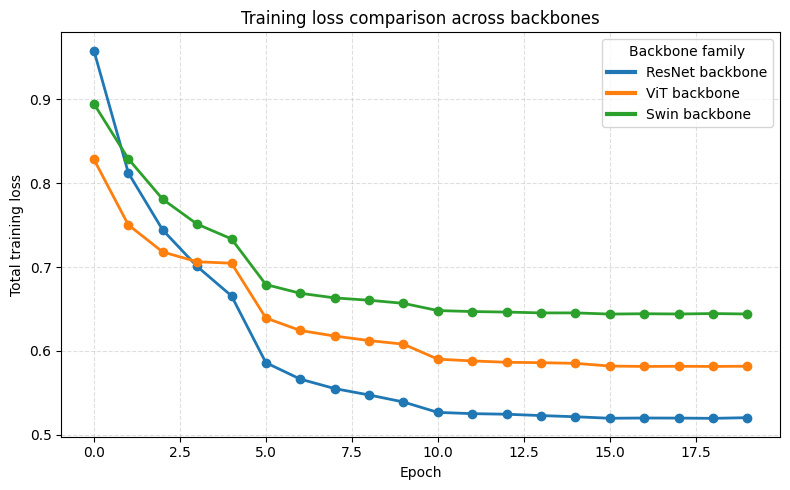

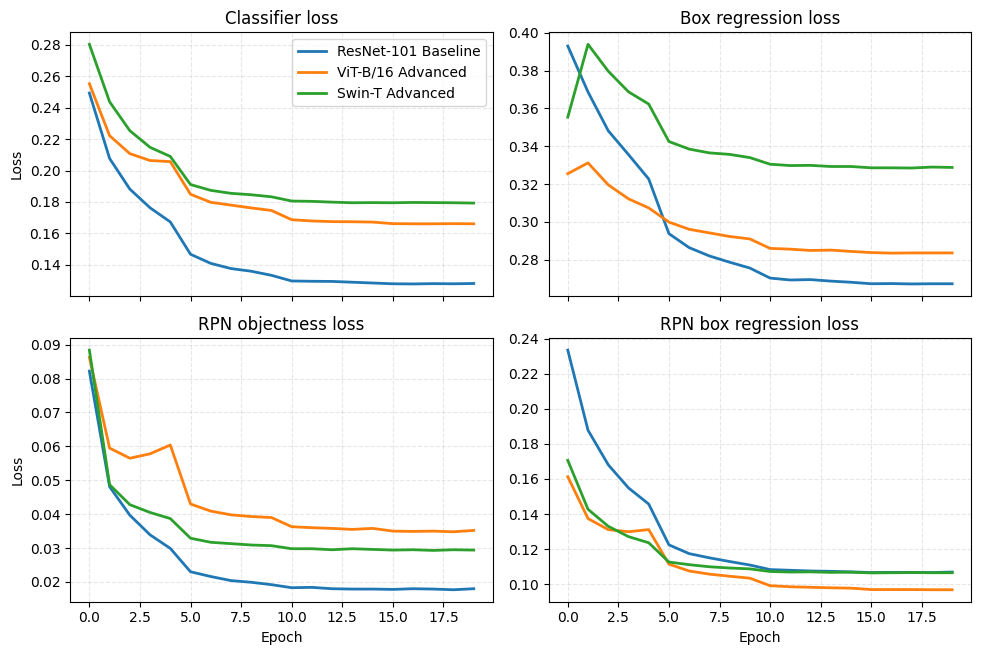

Parsed loss curves for models: ['ResNet-101 Baseline', 'ViT-B/16 Advanced', 'Swin-T Advanced']


In [50]:

import re
from collections import defaultdict, OrderedDict
import numpy as np
from matplotlib.lines import Line2D

LOG_ROOT = PROJECT_ROOT / "logs"
LOG_CONFIGS = OrderedDict([
    ("ResNet-101 Baseline", LOG_ROOT / "251016T215643_bbt-resnet101_train.log"),
    ("ViT-B/16 Advanced", LOG_ROOT / "251007T181754_bbt-vit_b_16_train.log"),
    ("Swin-T Advanced", LOG_ROOT / "251016T215418_bbt-swin_t_train.log"),
])

ARCH_COLORS = {
    "ResNet": "#1f77b4",
    "ViT": "#ff7f0e",
    "Swin": "#2ca02c",
}

SAVE_FIGURES = globals().get("SAVE_FIGURES", False)
IMAGES_DIR = PROJECT_ROOT / "reports" / "images"
if SAVE_FIGURES:
    IMAGES_DIR.mkdir(parents=True, exist_ok=True)

def infer_arch(model_name: str) -> str:
    if "ResNet" in model_name:
        return "ResNet"
    if "ViT" in model_name:
        return "ViT"
    if "Swin" in model_name:
        return "Swin"
    return "Other"

pattern = re.compile(r"Epoch (\d+) Losses: \{([^}]*)\}")
value_pattern = re.compile(r"'([^']+)': '([^']+)'")
loss_curves = {}

for model_name, log_path in LOG_CONFIGS.items():
    if not log_path.is_file():
        print(f"[Warning] Log file missing for {model_name}: {log_path}")
        continue

    epochs = []
    total_losses = []
    component_losses = defaultdict(list)

    with log_path.open() as f:
        for line in f:
            match = pattern.search(line)
            if not match:
                continue
            epoch = int(match.group(1))
            payload = match.group(2)
            total = 0.0
            matched_any = False
            for key, value in value_pattern.findall(payload):
                try:
                    val = float(value)
                except ValueError:
                    continue
                component_losses[key].append(val)
                total += val
                matched_any = True
            if matched_any:
                epochs.append(epoch)
                total_losses.append(total)

    if epochs:
        loss_curves[model_name] = {
            "epoch": epochs,
            "total_loss": total_losses,
            "components": component_losses,
        }

fig, ax = plt.subplots(figsize=(8, 5))
for model_name, stats in loss_curves.items():
    arch = infer_arch(model_name)
    color = ARCH_COLORS.get(arch, "#444444")
    ax.plot(stats["epoch"], stats["total_loss"], marker='o', color=color,
            linestyle='-', linewidth=2, label=model_name)

ax.set_xlabel("Epoch")
ax.set_ylabel("Total training loss")
ax.set_title("Training loss comparison across backbones")
ax.grid(True, linestyle='--', alpha=0.4)

handles = [Line2D([0], [0], color=color, linewidth=3, label=f"{arch} backbone")
           for arch, color in ARCH_COLORS.items()]
ax.legend(handles=handles, loc='upper right', title='Backbone family')

plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(IMAGES_DIR / "training_loss_total.png", dpi=200, bbox_inches='tight')
plt.show()

component_keys = ["loss_classifier", "loss_box_reg", "loss_objectness", "loss_rpn_box_reg"]
component_labels = {
    "loss_classifier": "Classifier loss",
    "loss_box_reg": "Box regression loss",
    "loss_objectness": "RPN objectness loss",
    "loss_rpn_box_reg": "RPN box regression loss",
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
axes = axes.flatten()

for component, ax in zip(component_keys, axes):
    plotted = False
    for model_name, stats in loss_curves.items():
        values = stats["components"].get(component)
        if not values:
            continue
        values = np.array(values, dtype=float)
        arch = infer_arch(model_name)
        color = ARCH_COLORS.get(arch, "#444444")
        ax.plot(stats["epoch"], values, color=color, linestyle='-', linewidth=2, label=model_name)
        plotted = True
    ax.set_title(component_labels[component])
    ax.grid(True, linestyle='--', alpha=0.3)
    if not plotted:
        ax.text(0.5, 0.5, "not logged", ha='center', va='center', transform=ax.transAxes,
                fontsize=10, color='gray')

for ax in axes[2:]:
    ax.set_xlabel("Epoch")
for ax in axes[::2]:
    ax.set_ylabel("Loss")

axes[0].legend(loc='upper right')

fig.tight_layout(rect=(0, 0, 1, 0.95))
if SAVE_FIGURES:
    fig.savefig(IMAGES_DIR / "training_loss_components.png", dpi=200, bbox_inches='tight')
plt.show()

print('Parsed loss curves for models:', list(loss_curves.keys()))


## Validation mAP Trends

Every two epochs the training script runs COCO evaluation on the Waymo and nuScenes validation splits. The cell below parses each log file to extract the mAP@0.50:0.95 trajectory per backbone and plots the curves for easy comparison.

In [51]:

import re
import numpy as np
from collections import OrderedDict, defaultdict
from matplotlib.lines import Line2D

LOG_ROOT = PROJECT_ROOT / "logs"
LOG_CONFIGS = OrderedDict([
    ("ResNet-101 Baseline", LOG_ROOT / "251016T215643_bbt-resnet101_train.log"),
    ("ViT-B/16 Advanced", LOG_ROOT / "251007T181754_bbt-vit_b_16_train.log"),
    ("Swin-T Advanced", LOG_ROOT / "251016T215418_bbt-swin_t_train.log"),
])

MODEL_STYLES = {
    "ResNet-101 Baseline": {"color": "#1f77b4", "marker": "o", "linestyle": "-"},
    "ViT-B/16 Advanced": {"color": "#ff7f0e", "marker": "s", "linestyle": "--"},
    "Swin-T Advanced": {"color": "#2ca02c", "marker": "^", "linestyle": "-."},
}

METRIC_SPECS = OrderedDict([
    ("AP@[0.50:0.95]", "mAP@[0.50:0.95]"),
    ("AP@0.50", "AP@0.50"),
    ("AP@0.75", "AP@0.75"),
    ("AR@100", "AR@100"),
])

SAVE_FIGURES = globals().get("SAVE_FIGURES", False)
IMAGES_DIR = PROJECT_ROOT / "reports" / "images"
if SAVE_FIGURES:
    IMAGES_DIR.mkdir(parents=True, exist_ok=True)

def infer_arch(model_name: str) -> str:
    if "ResNet" in model_name:
        return "ResNet"
    if "ViT" in model_name:
        return "ViT"
    if "Swin" in model_name:
        return "Swin"
    return "Other"

def build_metric_key(metric_type: str, descriptor: str) -> str | None:
    descriptor = descriptor.replace('\u00a0', ' ')
    iou_match = re.search(r'IoU=([^|]+)', descriptor)
    area_match = re.search(r'area=([^|]+)', descriptor)
    maxdets_match = re.search(r'maxDets=([^\]]+)', descriptor)

    iou = iou_match.group(1).strip() if iou_match else None
    area = area_match.group(1).strip().lower() if area_match else 'all'
    maxdets = maxdets_match.group(1).strip() if maxdets_match else None

    if metric_type == 'AP':
        if area != 'all':
            return f"AP_{area}"
        if iou == '0.50:0.95':
            return 'AP@[0.50:0.95]'
        if iou == '0.50':
            return 'AP@0.50'
        if iou == '0.75':
            return 'AP@0.75'
    elif metric_type == 'AR':
        if area != 'all':
            return f"AR_{area}"
        if maxdets:
            return f"AR@{maxdets}"
    return None

def parse_validation_metrics(log_path):
    datasets = {"Waymo": defaultdict(dict), "nuScenes": defaultdict(dict)}
    if not log_path.is_file():
        print(f"[Warning] Missing log: {log_path}")
        return datasets

    current_epoch = None
    current_dataset = None
    epoch_pattern = re.compile(r"Epoch\s+(\d+)/")
    metric_pattern = re.compile(r"Average (Precision|Recall).*@\[(.*)\] = ([^\s]+)")

    with log_path.open() as fh:
        for raw_line in fh:
            line = raw_line.strip()
            if not line:
                continue
            if "Validation @ Epoch" in line:
                match = epoch_pattern.search(line)
                if match:
                    current_epoch = int(match.group(1))
                continue
            if "Final Test Results" in line:
                current_epoch = None
                current_dataset = None
                continue
            if line.startswith('---') and 'Validation' in line:
                if 'Waymo' in line:
                    current_dataset = 'Waymo'
                elif 'Nuscenes' in line or 'nuScenes' in line:
                    current_dataset = 'nuScenes'
                else:
                    current_dataset = None
                continue
            if current_dataset is None or current_epoch is None:
                continue
            metric_match = metric_pattern.search(line)
            if not metric_match:
                continue
            metric_type = 'AP' if metric_match.group(1) == 'Precision' else 'AR'
            descriptor = metric_match.group(2)
            value_str = metric_match.group(3)
            try:
                value = float(value_str)
            except ValueError:
                continue
            metric_key = build_metric_key(metric_type, descriptor)
            if metric_key is None:
                continue
            datasets[current_dataset][metric_key][current_epoch] = value

    results = {}
    for dataset, metrics in datasets.items():
        results[dataset] = {}
        for metric_key, epoch_map in metrics.items():
            epochs_sorted = sorted(epoch_map.keys())
            values = [epoch_map[e] for e in epochs_sorted]
            results[dataset][metric_key] = {
                "epoch": epochs_sorted,
                "values": values,
            }
    return results

validation_curves = {
    model_name: parse_validation_metrics(log_path)
    for model_name, log_path in LOG_CONFIGS.items()
}



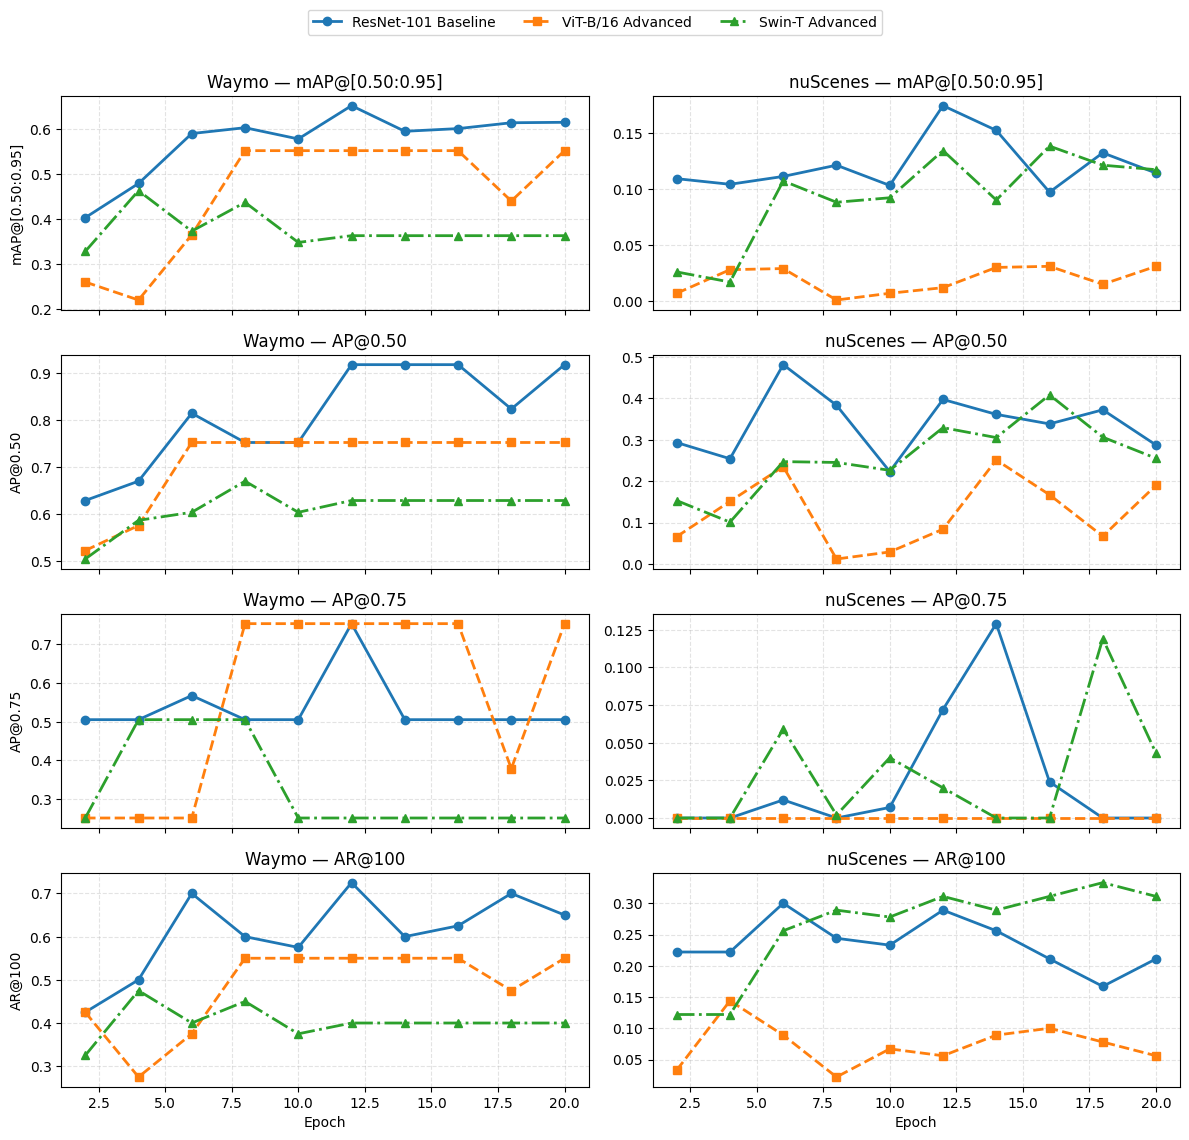

In [52]:

DATASETS = ['Waymo', 'nuScenes']
fig, axes = plt.subplots(len(METRIC_SPECS), len(DATASETS), figsize=(12, 2.8 * len(METRIC_SPECS)), sharex='col', sharey=False)
axes = np.atleast_2d(axes)

for row, (metric_key, metric_label) in enumerate(METRIC_SPECS.items()):
    for col, dataset in enumerate(DATASETS):
        ax = axes[row, col]
        plotted = False
        for model_name, curves in validation_curves.items():
            dataset_metrics = curves.get(dataset, {})
            metric_data = dataset_metrics.get(metric_key)
            if not metric_data:
                continue
            epochs = metric_data['epoch']
            values = np.array(metric_data['values'], dtype=float)
            values[values < 0] = np.nan
            if np.all(np.isnan(values)):
                continue
            style = MODEL_STYLES.get(model_name, {"color": "#444444", "marker": "o", "linestyle": "-"})
            ax.plot(epochs, values, color=style["color"], linestyle=style["linestyle"], linewidth=2,
                    marker=style["marker"], markersize=6, label=model_name)
            plotted = True
        ax.set_title(f"{dataset} — {metric_label}")
        ax.grid(True, linestyle='--', alpha=0.35)
        if row == len(METRIC_SPECS) - 1:
            ax.set_xlabel("Epoch")
        if col == 0:
            ax.set_ylabel(metric_label)
        if not plotted:
            ax.text(0.5, 0.5, "not available", ha='center', va='center', transform=ax.transAxes,
                    fontsize=10, color='gray')

handles = [Line2D([0], [0], color=style["color"], linestyle=style["linestyle"], marker=style["marker"],
                  linewidth=2, markersize=6, label=model_name)
           for model_name, style in MODEL_STYLES.items()]
fig.legend(handles=handles, loc='upper center', ncol=len(MODEL_STYLES), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=(0, 0, 1, 0.97))

if SAVE_FIGURES:
    fig.savefig(IMAGES_DIR / "validation_metrics_grid.png", dpi=200, bbox_inches='tight')

plt.show()

## Visualize Predictions

=== Waymo Predictions ===


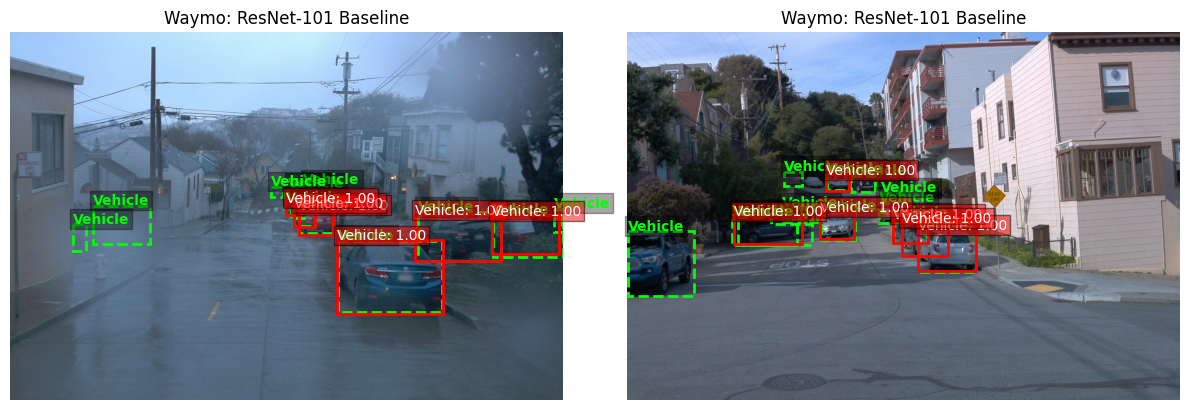

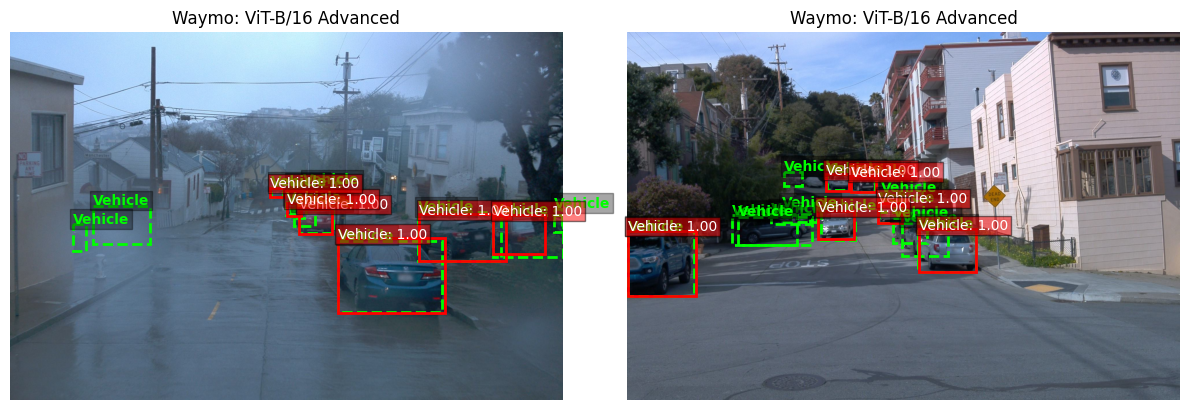

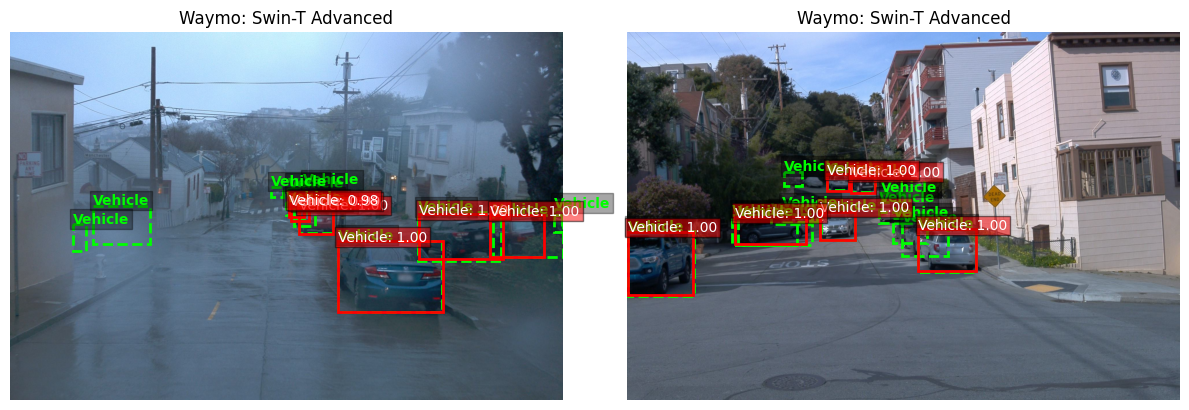

=== nuScenes Predictions ===


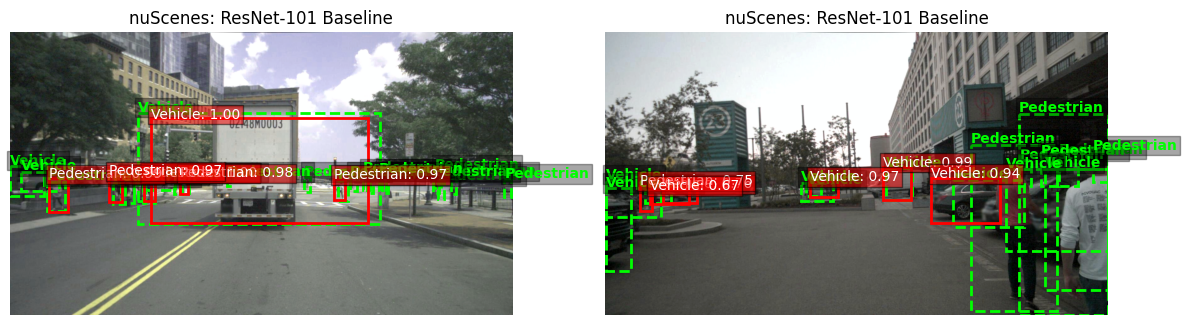

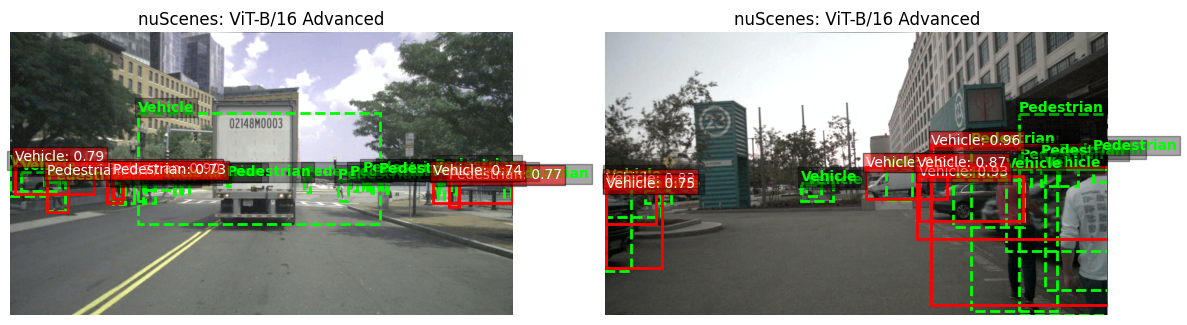

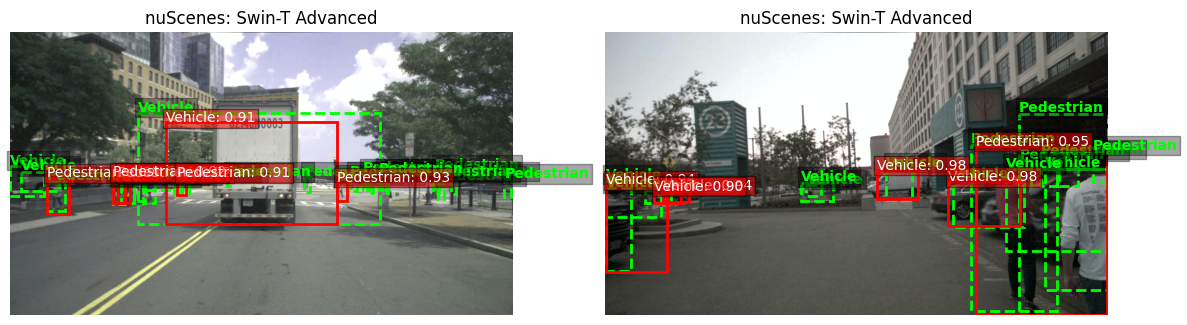

In [53]:
EVAL_SAMPLES = {
    "Waymo": waymo_samples,
    "nuScenes": nuscenes_samples,
}

for dataset_name, samples in EVAL_SAMPLES.items():
    print(f"=== {dataset_name} Predictions ===")
    for model_name, model in MODELS.items():
        predictions = run_inference(model, samples, device)
        visualize_predictions(model_name, dataset_name, samples, predictions, score_threshold=0.4)
